In [44]:
import pandas as pd
import numpy as np
import colorsys
import matplotlib.pyplot as plt

def get_hsv_metrics(row):
    sats = []
    lums = []
    for i in range(1, 6):
        r, g, b = row[f'C{i}_R'], row[f'C{i}_G'], row[f'C{i}_B']
        if pd.notnull(r):
            # Převod na 0-1 pro colorsys
            r_n, g_n, b_n = r/255.0, g/255.0, b/255.0
            # Hue, Saturation, Value
            h, s, v = colorsys.rgb_to_hsv(r_n, g_n, b_n)
            # Luminance
            lum = 0.299*r + 0.587*g + 0.114*b
            sats.append(s)
            lums.append(lum)
        
    return pd.Series([np.mean(sats), np.mean(lums)])

def analyze_genres_colors(df):
    # Separate genres into individual rows
    df_genres = df.copy()
    df_genres['Genres'] = df_genres['Genres'].fillna('').str.split('|')
    df_exploded = df_genres.explode('Genres')
    df_exploded = df_exploded[df_exploded['Genres'] != ""]

    # calculate metrics
    metrics = df_exploded.apply(get_hsv_metrics, axis=1)
    df_exploded[['Avg_Saturation', 'Avg_Luminance']] = metrics

    return df_exploded

def analyze_theme_colors(df):
    # Separate themes into individual rows
    df_themes = df.copy()
    df_themes['Themes'] = df_themes['Themes'].fillna('').str.split('|')
    df_exploded = df_themes.explode('Themes')
    df_exploded = df_exploded[df_exploded['Themes'] != ""]

    # calculate metrics
    metrics = df_exploded.apply(get_hsv_metrics, axis=1)
    df_exploded[['Avg_Saturation', 'Avg_Luminance']] = metrics

    return df_exploded

# Load data
df = pd.read_csv('C:\\Users\\nina\\Documents\\UNI\\SEM\\thesis\\coding\\game_color_analysis\\data\\game_data.csv')
analyzed_genre_df = analyze_genres_colors(df)
analyzed_theme_df = analyze_theme_colors(df)

summary_genre = analyzed_genre_df.groupby(['Decade', 'Genres'])[['Avg_Saturation', 'Avg_Luminance']].mean().reset_index()
summary_theme = analyzed_theme_df.groupby(['Decade', 'Themes'])[['Avg_Saturation', 'Avg_Luminance']].mean().reset_index()
# print(summary)


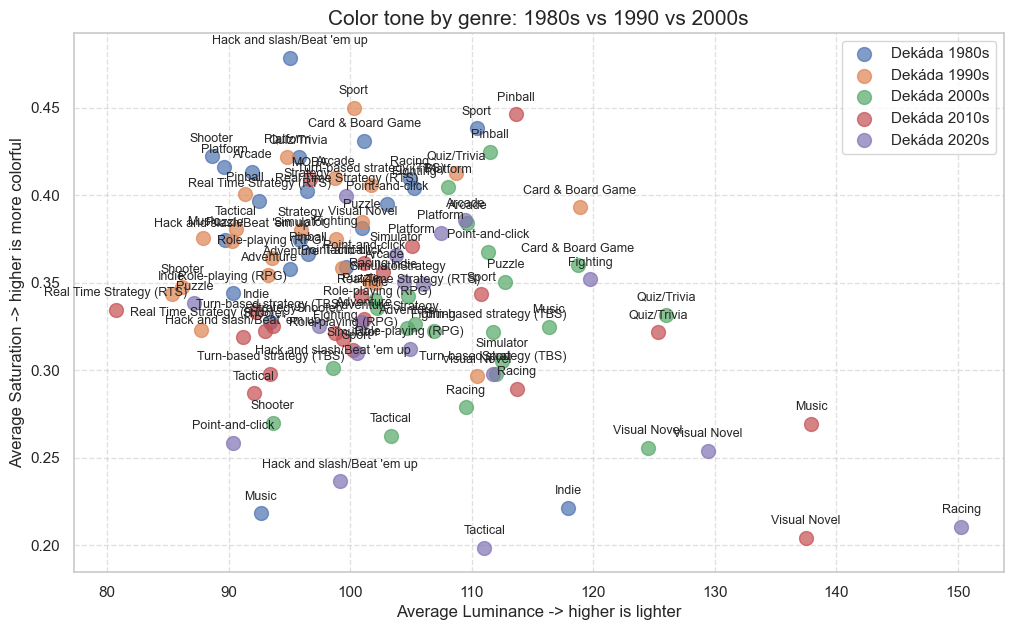

In [46]:
plt.figure(figsize=(12, 7))

for decade in [1980, 1990, 2000, 2010, 2020]:
    data = summary_genre[summary_genre['Decade'] == decade]
    plt.scatter(data['Avg_Luminance'], data['Avg_Saturation'], 
                label=f'Dekáda {decade}s', s=100, alpha=0.7)
    
    for i, row in data.iterrows():
        plt.annotate(row['Genres'], (row['Avg_Luminance'], row['Avg_Saturation']), 
                     textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.title('Color tone by genre: 1980s vs 1990 vs 2000s', fontsize=15)
plt.xlabel('Average Luminance -> higher is lighter', fontsize=12)
plt.ylabel('Average Saturation -> higher is more colorful', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

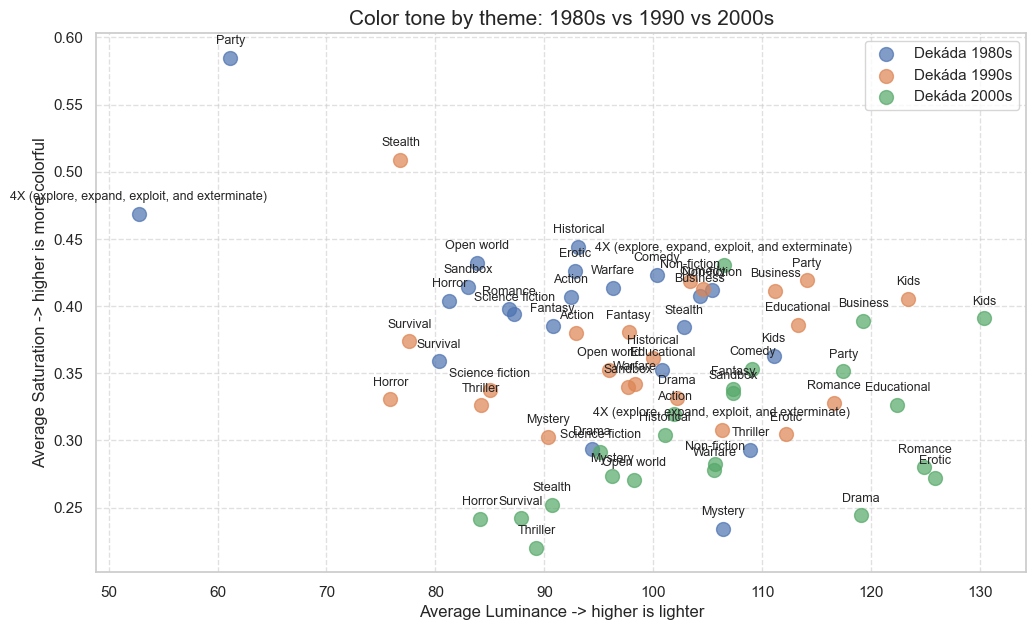

In [47]:
plt.figure(figsize=(12, 7))

for decade in [1980, 1990, 2000]:
    data = summary_theme[summary_theme['Decade'] == decade]
    plt.scatter(data['Avg_Luminance'], data['Avg_Saturation'], 
                label=f'Dekáda {decade}s', s=100, alpha=0.7)
    
    for i, row in data.iterrows():
        plt.annotate(row['Themes'], (row['Avg_Luminance'], row['Avg_Saturation']), 
                     textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.title('Color tone by theme: 1980s vs 1990 vs 2000s', fontsize=15)
plt.xlabel('Average Luminance -> higher is lighter', fontsize=12)
plt.ylabel('Average Saturation -> higher is more colorful', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

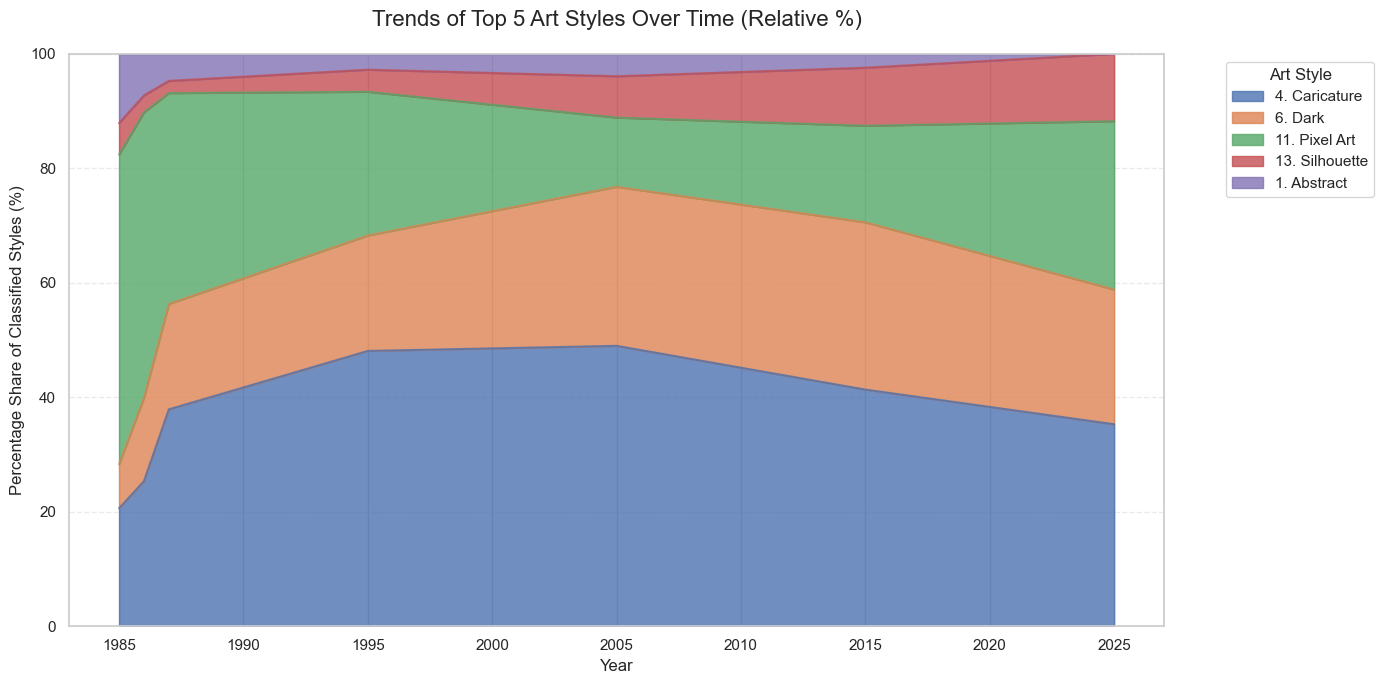

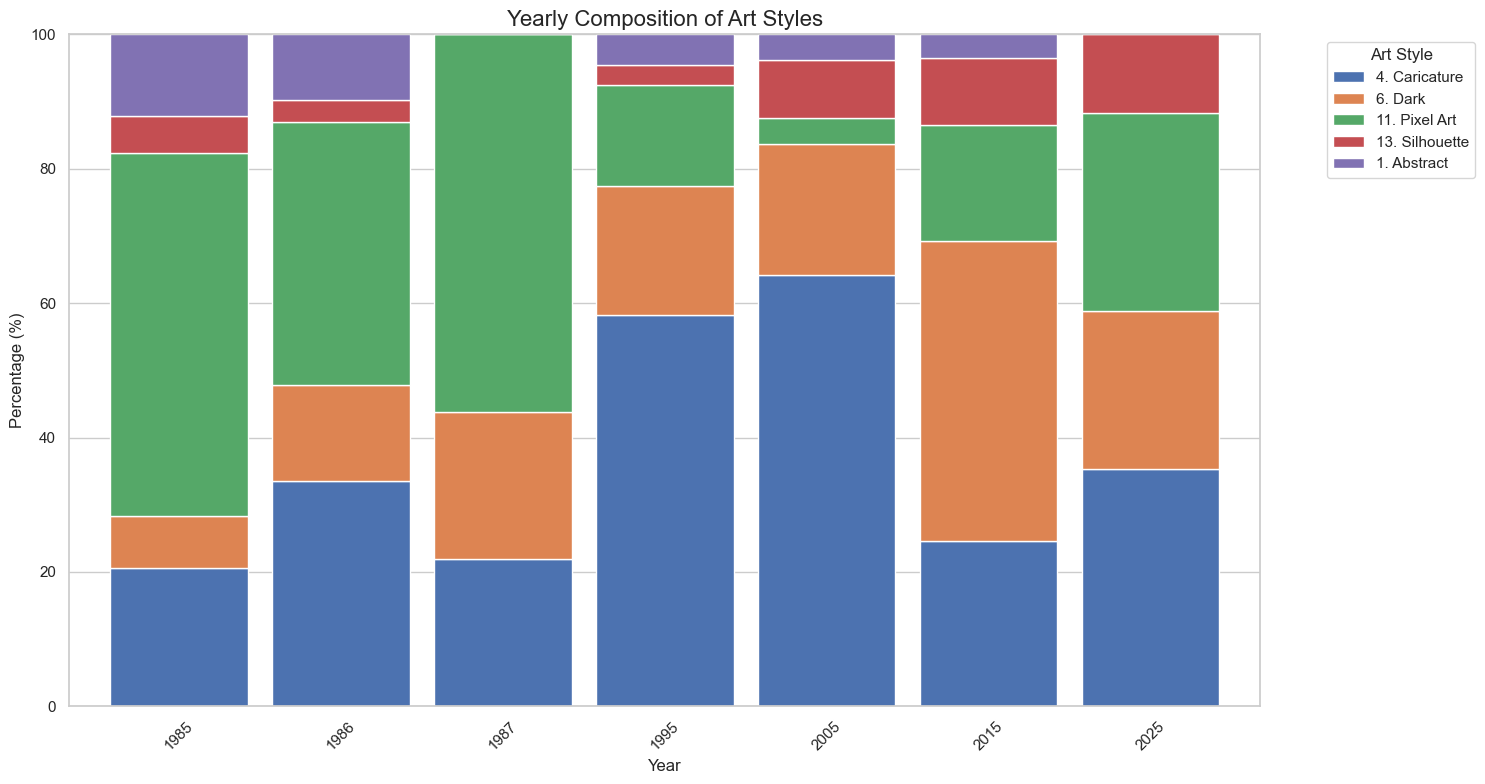

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CONFIGURATION & MAPPING ---
# Based on your provided hierarchy
ART_STYLE_MAP = {
    "1. Abstract": ["abstract", "psychedelic", "text-based", "experimental visuals"],
    "2. Black & White": ["black and white", "monochrome", "noir", "greyscale"],
    "3. Bright": ["bright", "vibrant", "neon", "high contrast"],
    "4. Caricature": ["caricature", "stylized", "cartoon", "cel-shaded", "comic book", "anime", "manga", "watercolor"],
    "5. Colorful": ["colorful", "saturated", "multi-colored"],
    "6. Dark": ["dark", "gritty", "gloomy", "atmospheric horror"],
    "7. Handicraft": ["handicraft", "claymation", "papercraft", "hand-drawn", "puppet"],
    "8. Lego": ["lego", "blocky", "bricks"],
    "9. Maplike": ["maplike", "topographical", "isometric view", "tactical map"],
    "10. Minimalism": ["minimalism", "minimalist", "flat art", "simple visuals"],
    "11. Pixel Art": ["pixel art", "8-bit", "16-bit", "retro graphics", "sprite"],
    "12. Realism": ["realism", "photorealistic", "photorealism", "illusionism", "televisualism", "high fidelity", "3d realism"],
    "13. Silhouette": ["silhouette", "shadow", "limbo-esque"]
}

def classify_game(row):
    # Safely combine text fields for searching
    text = f"{row.get('Keywords', '')} {row.get('Themes', '')} {row.get('Game', '')}".lower()
    
    if not text.strip():
        return "Unclassified"

    found_styles = []
    for style, keywords in ART_STYLE_MAP.items():
        if any(word in text for word in keywords):
            found_styles.append(style)
    
    return "|".join(found_styles) if found_styles else "Unclassified"

# --- 2. DATA PROCESSING ---

# 1. Load Data
# df = pd.read_csv('your_igdb_data.csv') # Ensure your CSV is loaded

# 2. Classify and Explode
df['art_style'] = df.apply(classify_game, axis=1)
plot_df = df[df['art_style'] != "Unclassified"].copy()

# Split pipe-separated styles into rows and reset index to fix the ValueError
plot_df['art_style'] = plot_df['art_style'].str.split('|')
plot_df = plot_df.explode('art_style').reset_index(drop=True)

# 3. Create Frequency Table
style_counts_per_year = pd.crosstab(plot_df['Year'], plot_df['art_style'])

# --- 3. FILTERING TOP 5 STYLES ---
# Identify the top 5 most frequent styles across the entire dataset
top_5_styles = plot_df['art_style'].value_counts().nlargest(5).index.tolist()

# Filter our table to only these 5 (and group others if desired, or just show top 5)
style_counts_top = style_counts_per_year[top_5_styles].copy()

# 4. Normalize to Percentages (100% stack)
style_percentages = style_counts_top.div(style_counts_top.sum(axis=1), axis=0) * 100

# Optional: Apply a 3-year rolling average to smooth out "noisy" years
style_percentages_smooth = style_percentages.rolling(window=3, center=True).mean().fillna(style_percentages)

# --- 4. VISUALIZATION ---

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

# Figure 1: Area Chart (Smoothed)
plt.figure(figsize=(14, 7))
style_percentages_smooth.plot(kind='area', stacked=True, ax=plt.gca(), alpha=0.8)

plt.title(f"Trends of Top {len(top_5_styles)} Art Styles Over Time (Relative %)", fontsize=16, pad=20)
plt.ylabel("Percentage Share of Classified Styles (%)")
plt.xlabel("Year")
plt.ylim(0, 100)
plt.legend(title="Art Style", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Figure 2: 100% Stacked Bar (Raw data)
ax = style_percentages.plot(kind='bar', stacked=True, figsize=(15, 8), width=0.85)
plt.title("Yearly Composition of Art Styles", fontsize=16)
plt.ylabel("Percentage (%)")
plt.xlabel("Year")
plt.legend(title="Art Style", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

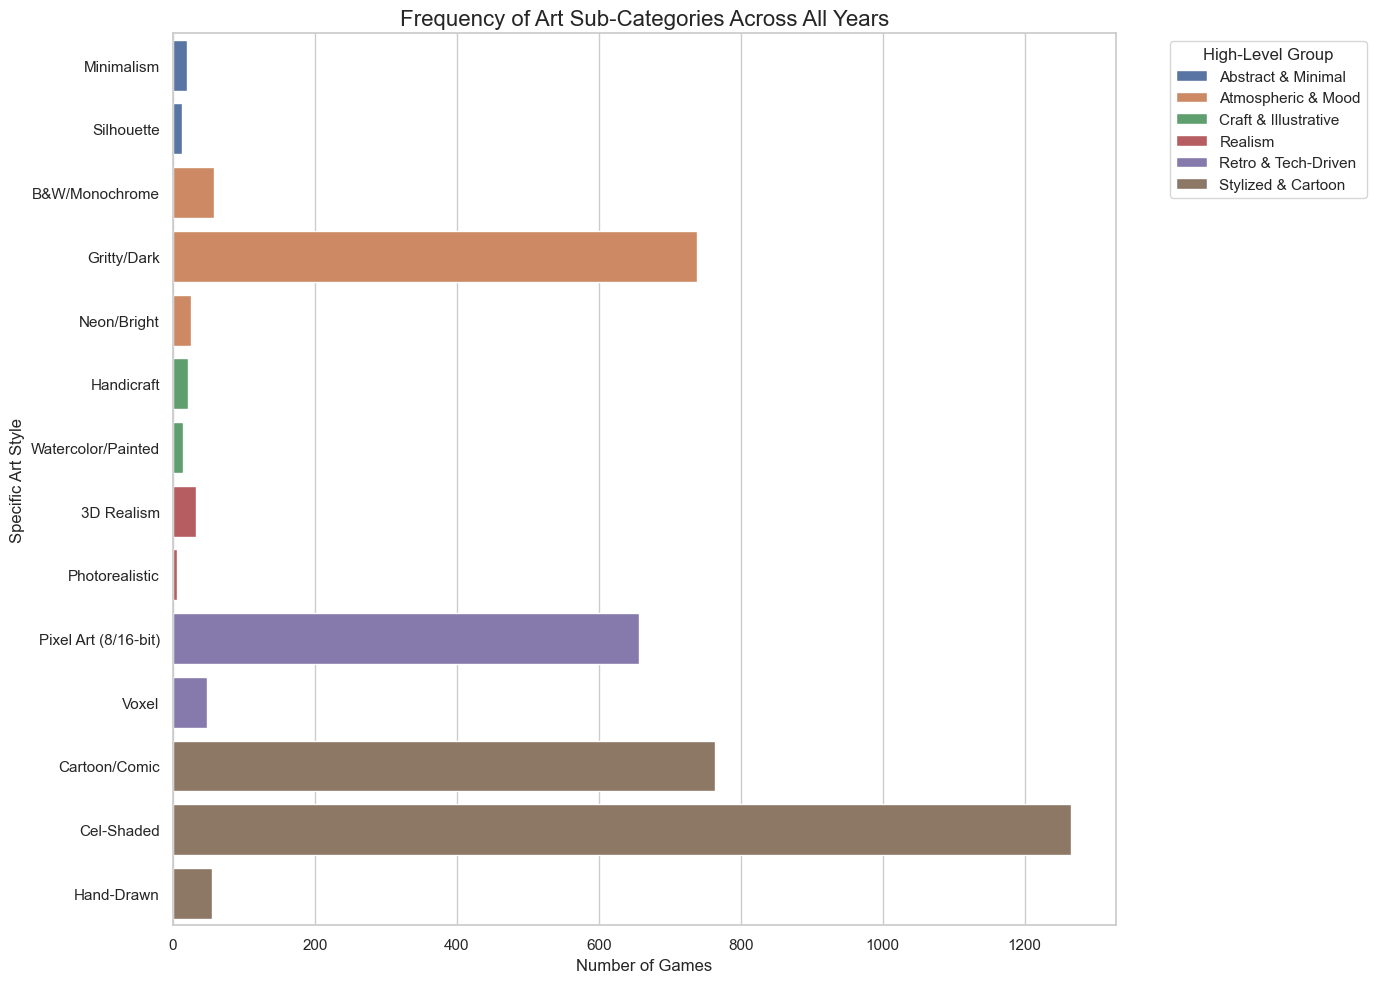

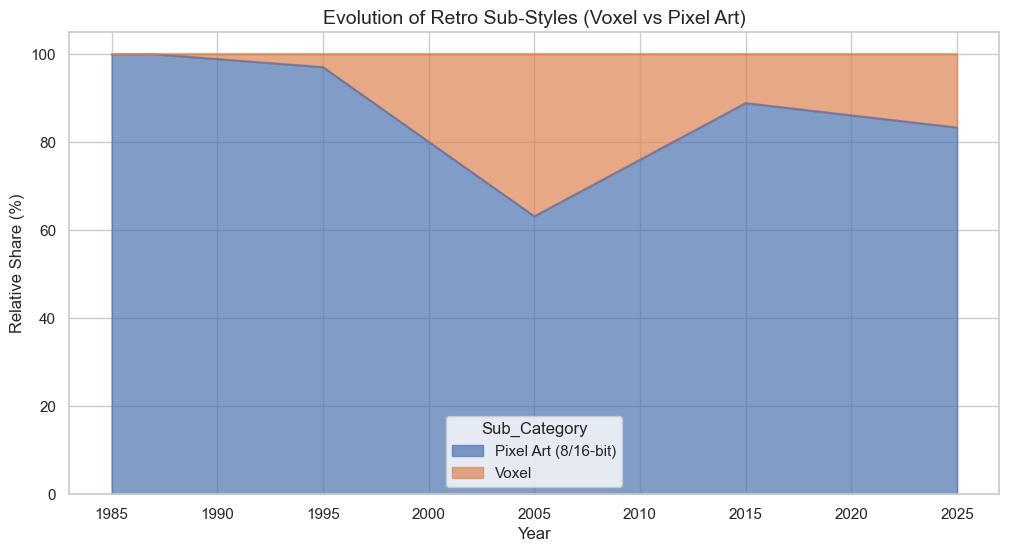

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. NESTED TAXONOMY DEFINITION ---
SUB_CATEGORY_MAP = {
    "Realism": {
        "Photorealistic": ["photorealistic", "photorealism", "high-fidelity"],
        "Semi-Realistic": ["semi-realistic", "illusionism", "televisualism"],
        "3D Realism": ["3d realism", "realistic"]
    },
    "Stylized & Cartoon": {
        "Cel-Shaded": ["cel-shaded", "anime", "manga"],
        "Cartoon/Comic": ["cartoon", "comic", "caricature", "exaggerated"],
        "Hand-Drawn": ["hand-drawn", "stylized"]
    },
    "Retro & Tech-Driven": {
        "Pixel Art (8/16-bit)": ["pixel art", "8-bit", "16-bit", "pixelated"],
        "Voxel": ["voxel", "blocky", "lego"],
        "Retro Graphics": ["retro graphics"]
    },
    "Abstract & Minimal": {
        "Minimalism": ["minimalist", "minimalism", "simplified"],
        "Flat/Vector": ["flat art", "flat design", "vector art"],
        "Silhouette": ["silhouette", "text-based"]
    },
    "Atmospheric & Mood": {
        "B&W/Monochrome": ["noir", "monochrome", "black and white", "monochromatic"],
        "Neon/Bright": ["neon", "vibrant", "bright", "psychedelic"],
        "Gritty/Dark": ["gritty", "dark", "gloomy"]
    },
    "Craft & Illustrative": {
        "Handicraft": ["claymation", "papercraft", "handicraft"],
        "Watercolor/Painted": ["watercolor", "hand-painted", "illustration"],
        "Maplike": ["maplike"]
    }
}

def classify_sub_styles(row):
    text = f"{row.get('Keywords', '')} {row.get('Themes', '')} {row.get('Game', '')}".lower()
    found_subs = []
    
    for high_level, subs in SUB_CATEGORY_MAP.items():
        for sub_name, keywords in subs.items():
            if any(word in text for word in keywords):
                # We store as "High Level: Sub Style"
                found_subs.append(f"{high_level}: {sub_name}")
                
    return "|".join(found_subs) if found_subs else "Unclassified"

# --- 2. PROCESSING ---

df['sub_styles'] = df.apply(classify_sub_styles, axis=1)

# Explode to handle multiple sub-styles per game
sub_df = df[df['sub_styles'] != "Unclassified"].copy()
sub_df['sub_styles'] = sub_df['sub_styles'].str.split('|')
sub_df = sub_df.explode('sub_styles').reset_index(drop=True)

# Split the combined string back into two columns for better plotting
sub_df[['Parent_Category', 'Sub_Category']] = sub_df['sub_styles'].str.split(': ', expand=True)


# 1. Calculate the frequency of every sub-category
sub_counts = sub_df.groupby(['Parent_Category', 'Sub_Category']).size().reset_index(name='Count')

# 2. Plotting the distribution of sub-categories within their parents
plt.figure(figsize=(14, 10))
sns.barplot(data=sub_counts, y='Sub_Category', x='Count', hue='Parent_Category', dodge=False)

plt.title("Frequency of Art Sub-Categories Across All Years", fontsize=16)
plt.xlabel("Number of Games")
plt.ylabel("Specific Art Style")
plt.legend(title="High-Level Group", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Filter for just the Retro category
retro_only = sub_df[sub_df['Parent_Category'] == "Retro & Tech-Driven"]

# Create percentage table for Retro sub-styles
retro_crosstab = pd.crosstab(retro_only['Year'], retro_only['Sub_Category'])
retro_pct = retro_crosstab.div(retro_crosstab.sum(axis=1), axis=0) * 100

# Plotting
retro_pct.plot(kind='area', stacked=True, figsize=(12, 6), alpha=0.7)
plt.title("Evolution of Retro Sub-Styles (Voxel vs Pixel Art)", fontsize=14)
plt.ylabel("Relative Share (%)")
plt.show()


